Q1)- Perform this transformation using the Torchvision package in PyTorch.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cars_train_data.csv to cars_train_data.csv


In [ ]:
uploaded = files.upload()

Saving cars_train.zip to cars_train.zip


In [ ]:
!unzip cars_train.zip -d /content/cars_train

Archive:  cars_train.zip
   creating: /content/cars_train/cars_train/
  inflating: /content/cars_train/cars_train/00001.jpg  
  inflating: /content/cars_train/cars_train/00002.jpg  
  inflating: /content/cars_train/cars_train/00003.jpg  
  inflating: /content/cars_train/cars_train/00004.jpg  
  inflating: /content/cars_train/cars_train/00005.jpg  
  inflating: /content/cars_train/cars_train/00006.jpg  
  inflating: /content/cars_train/cars_train/00007.jpg  
  inflating: /content/cars_train/cars_train/00008.jpg  
  inflating: /content/cars_train/cars_train/00009.jpg  
  inflating: /content/cars_train/cars_train/00010.jpg  
  inflating: /content/cars_train/cars_train/00011.jpg  
  inflating: /content/cars_train/cars_train/00012.jpg  
  inflating: /content/cars_train/cars_train/00013.jpg  
  inflating: /content/cars_train/cars_train/00014.jpg  
  inflating: /content/cars_train/cars_train/00015.jpg  
  inflating: /content/cars_train/cars_train/00016.jpg  
  inflating: /content/cars_train/c

In [ ]:
import pandas as pd
from PIL import Image
import os
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), #tensor => (a 3D number array: 3 colors × 224 × 224).
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #RGB
])

def load_and_preprocess_image(image_path, x1, y1, x2, y2):
    image = Image.open(image_path).convert('RGB')
    cropped_image = image.crop((x1, y1, x2, y2))
    return preprocess(cropped_image)

csv_path = '/content/cars_train_data.csv'
image_dir = '/content/cars_train/cars_train/'
df = pd.read_csv(csv_path)

image_files = set(os.listdir(image_dir))
df_filtered = df[df['image'].isin(image_files)]
print(f"Processing {len(df_filtered)} images from CSV matching available files.")

preprocessed_images = []
for idx, row in df_filtered.iterrows():
    image_path = os.path.join(image_dir, row['image'])
    try:
        tensor_image = load_and_preprocess_image(image_path, row['x1'], row['y1'], row['x2'], row['y2'])
        preprocessed_images.append({'image': row['image'], 'tensor': tensor_image, 'class': row['Class']})
        print(f"Processed {row['image']}")
    except Exception as e:
        print(f"Error processing {row['image']}: {e}. Skipping.")

if preprocessed_images:
    print(f"Shape of first image: {preprocessed_images[0]['tensor'].shape}")
    print(f"Total images processed: {len(preprocessed_images)}")
else:
    print("No images processed successfully.")

Processing 100 images from CSV matching available files.
Processed 00001.jpg
Processed 00002.jpg
Processed 00003.jpg
Processed 00004.jpg
Processed 00005.jpg
Processed 00006.jpg
Processed 00007.jpg
Processed 00008.jpg
Processed 00009.jpg
Processed 00010.jpg
Processed 00011.jpg
Processed 00012.jpg
Processed 00013.jpg
Processed 00014.jpg
Processed 00015.jpg
Processed 00016.jpg
Processed 00017.jpg
Processed 00018.jpg
Processed 00019.jpg
Processed 00020.jpg
Processed 00021.jpg
Processed 00022.jpg
Processed 00023.jpg
Processed 00024.jpg
Processed 00025.jpg
Processed 00026.jpg
Processed 00027.jpg
Processed 00028.jpg
Processed 00029.jpg
Processed 00030.jpg
Processed 00031.jpg
Processed 00032.jpg
Processed 00033.jpg
Processed 00034.jpg
Processed 00035.jpg
Processed 00036.jpg
Processed 00037.jpg
Processed 00038.jpg
Processed 00039.jpg
Processed 00040.jpg
Processed 00041.jpg
Processed 00042.jpg
Processed 00043.jpg
Processed 00044.jpg
Processed 00045.jpg
Processed 00046.jpg
Processed 00047.jpg
Pro

Q2)- Create class C.

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

class C:
    def __init__(self):
        self.model = models.resnet18(pretrained=True)
        self.model = nn.Sequential(*list(self.model.children())[:-1]) # 512 numbers without label (last class)
        self.model.eval() #Just use the model, don’t learn

    def get_embedding(self, image_tensor):
        with torch.no_grad():  # No training
            embedding = self.model(image_tensor.unsqueeze(0))  # add 1 att the first (first batch)
            return embedding.squeeze().numpy()  #select just 512 values

Q3)- Using class C, calculate the image embeddings for all images.

In [ ]:
c = C()

embeddings = []
for item in preprocessed_images:
    image_tensor = item['tensor']
    embedding = c.get_embedding(image_tensor)
    embeddings.append({
        'image': item['image'],
        'embedding': embedding,  # 512-number array
        'class': item['class']
    })
    print(f"Generated embedding for {item['image']}")

print(f"Total embeddings: {len(embeddings)}")
print(f"Shape of first embedding: {embeddings[0]['embedding'].shape}")
print(f"number of values of first embedding: {embeddings[0]['embedding']}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Generated embedding for 00001.jpg
Generated embedding for 00002.jpg
Generated embedding for 00003.jpg
Generated embedding for 00004.jpg
Generated embedding for 00005.jpg
Generated embedding for 00006.jpg
Generated embedding for 00007.jpg
Generated embedding for 00008.jpg
Generated embedding for 00009.jpg
Generated embedding for 00010.jpg
Generated embedding for 00011.jpg
Generated embedding for 00012.jpg
Generated embedding for 00013.jpg
Generated embedding for 00014.jpg
Generated embedding for 00015.jpg
Generated embedding for 00016.jpg
Generated embedding for 00017.jpg
Generated embedding for 00018.jpg
Generated embedding for 00019.jpg
Generated embedding for 00020.jpg
Generated embedding for 00021.jpg
Generated embedding for 00022.jpg
Generated embedding for 00023.jpg
Generated embedding for 00024.jpg
Generated embedding for 00025.jpg
Generated embedding for 00026.jpg
Generated embedding for 00027.jpg
Generated embedding for 00028.jpg
Generated embedding for 00029.jpg
Generated embe

Q4)- Store the image embeddings in a CSV file.

In [ ]:
import pandas as pd
import numpy as np

embedding_data = []
for item in embeddings:
    row = {'image': item['image'], 'class': item['class']}
    for i, value in enumerate(item['embedding']):
        row[f'emb_{i}'] = value
    embedding_data.append(row)

df = pd.DataFrame(embedding_data)


csv_path = 'image_embeddings.csv'
df.to_csv(csv_path, index=False)
print(f"Saved embeddings to {csv_path}")

print(f"Rows in CSV: {len(df)}")
print(f"Columns in CSV: {len(df.columns)}")
print(df.head())

Saved embeddings to image_embeddings.csv
Rows in CSV: 100
Columns in CSV: 514
       image  class     emb_0     emb_1     emb_2     emb_3     emb_4  \
0  00001.jpg     14  1.078022  3.323728  4.355687  0.706883  2.648814   
1  00002.jpg      3  0.709358  3.782959  3.086234  0.551719  1.630380   
2  00003.jpg     91  1.922893  1.900808  1.285944  0.097727  3.150282   
3  00004.jpg    134  1.053708  3.186613  1.772998  0.580220  3.322468   
4  00005.jpg    106  0.770389  2.335007  1.218111  0.020585  2.856947   

      emb_5     emb_6     emb_7  ...   emb_502   emb_503   emb_504   emb_505  \
0  1.919825  0.669183  1.034461  ...  0.698162  3.271658  0.028000  0.185403   
1  1.718434  0.558059  0.081345  ...  0.325259  0.996954  0.477800  0.609861   
2  0.296099  0.733269  1.267517  ...  0.139707  1.118076  0.206772  0.165412   
3  1.007847  1.260587  0.449619  ...  0.712684  0.447315  0.093110  1.731348   
4  0.622527  1.644446  1.180872  ...  0.537755  1.199680  0.069541  0.074490   

  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Q5)- Create a Spark DataFrame that contains the image embeddings.


In [ ]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ImageSimilarity") \
    .getOrCreate()

csv_path = '/content/image_embeddings.csv'
embeddings_df = spark.read.csv(csv_path, header=True, inferSchema=True)

embeddings_df.show(5)

print(f"Number of rows: {embeddings_df.count()}")
print("Schema:")
embeddings_df.printSchema()

+---------+-----+----------+---------+---------+-----------+---------+----------+---------+----------+----------+----------+-----------+----------+----------+---------+-----------+-----------+----------+----------+----------+----------+----------+---------+----------+----------+----------+---------+----------+---------+-----------+----------+----------+-----------+---------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+-----------+----------+-----------+----------+----------+---------+------------+----------+-----------+----------+-----------+----------+----------+----------+----------+---------+----------+----------+-----------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+-----------+-----------+---------+----------+----------+----------+------------+----------+----------+----------+-----------+----------+------

Q6)- The PySpark LSH implementation requires a vector column as input. Perform a
transformation to represent the relevant columns as a single vector.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler

spark = SparkSession.builder.appName("LSH Preparation").getOrCreate()


df_spark = spark.createDataFrame(df)

embedding_cols = [f"emb_{i}" for i in range(512)]

assembler = VectorAssembler(
    inputCols=embedding_cols,
    outputCol="features"
)

df_with_vectors = assembler.transform(df_spark)

df_with_vectors.select("image", "class", "features").show(5, truncate=False)

df_with_vectors.printSchema()

+---------+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Q7)- Create a model using the BucketedRandomProjection.

In [ ]:
from pyspark.ml.feature import BucketedRandomProjectionLSH

brp = BucketedRandomProjectionLSH(
    inputCol="features",
    outputCol="hashes",
    bucketLength=2.0,
    numHashTables=3     # fncts
)

lsh_model = brp.fit(df_with_vectors)

print("LSH model created successfully!")


LSH model created successfully!


Q8)- Transform the DataFrame using the newly created LSH model. The resulting DataFrame
will include a hash column containing a hashed representation of the image embeddings.

In [ ]:
hashed_df = lsh_model.transform(df_with_vectors)

hashed_df.select("image", "class", "features", "hashes").show(5, truncate=False)
hashed_df.printSchema()


# |[[-1.0], [0.0], [-1.0]] | => 3 rules(fncts) of hashage => bucket IDs
# Negative (-1.0): The vector is on one side of a line.
# Zero (0.0): Near the middle.
# Positive (1.0): On the other side.

+---------+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Q9)- Select a random image.

In [ ]:
import random

image_list = hashed_df.select("image").rdd.flatMap(lambda x: x).collect()

random_image = random.choice(image_list)

print(f"the random image is => {random_image}")

random_row = hashed_df.filter(hashed_df.image == random_image).first()
print(f"Details of selected image: image={random_row['image']}, class={random_row['class']}")

the random image is => 00092.jpg
Details of selected image: image=00092.jpg, class=138


Q10) Convert This Image into a Vector Format

In [ ]:
random_vector = random_row["features"]

print(f"Vector for {random_image} (first 10 elements): {random_vector[:10]}")
print(f"Vector length: {len(random_vector)}")

Vector for 00092.jpg (first 10 elements): [1.74273574 2.89170146 1.39486945 0.03306191 1.32391798 1.28737378
 0.77066058 0.18363902 1.27060378 1.7732265 ]
Vector length: 512


Q11) Perform an Approximate Search for the Five Nearest Neighbors

In [ ]:
neighbors = lsh_model.approxNearestNeighbors(
    hashed_df,
    key=random_vector,
    numNearestNeighbors=5,
    distCol="distance"
)

neighbors.select("image", "class", "distance").show(truncate=False)

+---------+-----+------------------+
|image    |class|distance          |
+---------+-----+------------------+
|00092.jpg|138  |0.0               |
|00087.jpg|49   |11.95270795084616 |
|00075.jpg|188  |12.414463840807468|
|00022.jpg|36   |13.30496192001292 |
|00027.jpg|184  |13.430614044692028|
+---------+-----+------------------+



Q12) Display the Images That Correspond to the Five Neighbors

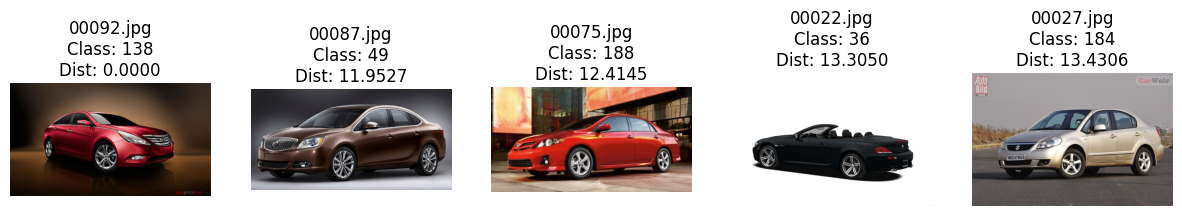

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

neighbor_images = neighbors.select("image").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(15, 3))
for i, img_name in enumerate(neighbor_images):
    img_path = os.path.join(image_dir, img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{img_name}\nClass: {neighbors.filter(neighbors.image == img_name).first()['class']}\nDist: {neighbors.filter(neighbors.image == img_name).first()['distance']:.4f}")
        plt.axis("off")
    else:
        print(f"Image not found: {img_path}")
plt.show()

In [ ]:
print("Embeddings and Hashes for the Five Nearest Neighbors:")
neighbors.select("image", "features", "hashes").show(5, truncate=False)

Embeddings and Hashes for the Five Nearest Neighbors:
+---------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------